# NITheCS Project
## EVALUATING CONFORMAL PREDICTION FOR UNCERTAINTY QUANTIFICATION IN MACHINE LEARNING-BASED TEMPERATURE PREDICTION
***Khethiwe Ntshangase***

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL

from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from mapie.regression import SplitConformalRegressor


import warnings
warnings.filterwarnings("ignore")

### 2. Load Dataset

In [2]:
url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=-33.9833&longitude=18.6"
    "&start_date=2015-01-01"
    "&end_date=2025-12-31"
    "&daily=temperature_2m_max,temperature_2m_min,"
    "temperature_2m_mean,precipitation_sum"
    "&timezone=Africa/Johannesburg"
)

data = requests.get(url).json()

df = pd.DataFrame(data["daily"])
df["time"] = pd.to_datetime(df["time"])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df.head())
print(df.tail())

        time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  precipitation_sum
0 2015-01-01                24.4                18.6                 21.3                0.0
1 2015-01-02                23.5                17.3                 20.4                0.0
2 2015-01-03                24.2                15.6                 20.5                0.1
3 2015-01-04                23.5                17.7                 20.3                1.1
4 2015-01-05                22.2                18.3                 20.2                3.7
           time  temperature_2m_max  temperature_2m_min  temperature_2m_mean  precipitation_sum
4013 2025-12-27                27.9                17.0                 22.4                0.0
4014 2025-12-28                30.5                16.8                 23.7                0.0
4015 2025-12-29                35.6                17.9                 27.1                0.0
4016 2025-12-30                30.3                19.1   

In [3]:
df = df.rename(columns={
    "temperature_2m_max": "TMAX",
    "temperature_2m_min": "TMIN",
    "temperature_2m_mean": "TMEAN",
    "precipitation_sum": "PRCP"})
df.head()

,time,TMAX,TMIN,TMEAN,PRCP
0,2015-01-01,24.4,18.6,21.3,0.0
1,2015-01-02,23.5,17.3,20.4,0.0
2,2015-01-03,24.2,15.6,20.5,0.1
3,2015-01-04,23.5,17.7,20.3,1.1
4,2015-01-05,22.2,18.3,20.2,3.7


In [4]:
df = df.sort_values("time")
df = df.reset_index(drop=True)

### 3. Exploratory Data Analysis (EDA)

In [5]:
# Check for data information
print(df.info())

# Check data shape
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    4018 non-null   datetime64[us]
 1   TMAX    4018 non-null   float64       
 2   TMIN    4018 non-null   float64       
 3   TMEAN   4018 non-null   float64       
 4   PRCP    4018 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 157.1 KB
None
(4018, 5)


In [6]:
# Check for duplicates
print(df.duplicated().sum())

# Check for missing values
print(df.isnull().sum())

# Check for unique values
print(df.nunique())

# Check for data types
print(df.dtypes)

0
time     0
TMAX     0
TMIN     0
TMEAN    0
PRCP     0
dtype: int64
time     4018
TMAX      250
TMIN      201
TMEAN     191
PRCP      204
dtype: int64
time     datetime64[us]
TMAX            float64
TMIN            float64
TMEAN           float64
PRCP            float64
dtype: object


In [7]:
print (df.describe())

                      time         TMAX         TMIN        TMEAN         PRCP
count                 4018  4018.000000  4018.000000  4018.000000  4018.000000
mean   2020-07-01 12:00:00    22.248955    12.904878    17.204505     1.395495
min    2015-01-01 00:00:00    11.000000     0.000000     7.700000     0.000000
25%    2017-10-01 06:00:00    18.100000    10.200000    14.000000     0.000000
50%    2020-07-01 12:00:00    22.100000    13.000000    17.200000     0.000000
75%    2023-04-01 18:00:00    25.700000    15.900000    20.300000     0.500000
max    2025-12-31 00:00:00    37.400000    22.400000    28.000000    80.800000
std                    NaN     5.023921     3.859571     3.893225     4.418035


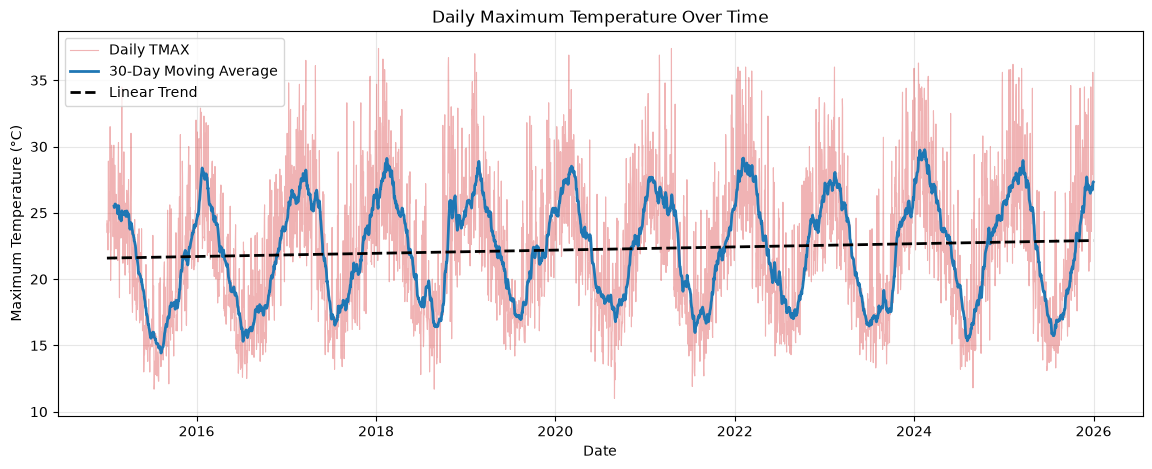

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Sort data
df = df.sort_values("time")

df["TMAX_30day_avg"] = df["TMAX"].rolling(window=30).mean()

x = mdates.date2num(df["time"])
y = df["TMAX"]

trend_coefficients = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend_coefficients)

plt.figure(figsize=(14, 5))

plt.plot(df["time"], df["TMAX"], color="tab:red", linewidth=0.8, alpha=0.35, label="Daily TMAX")
plt.plot(df["time"], df["TMAX_30day_avg"], color="tab:blue", linewidth=2, label="30-Day Moving Average")
plt.plot(df["time"], trend_line(x), color="black", linewidth=2, linestyle="--", label="Linear Trend")

plt.title("Daily Maximum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

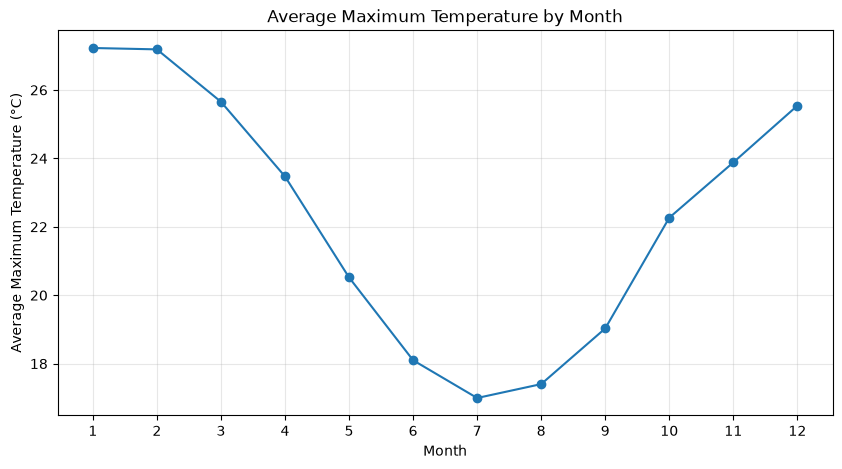

In [9]:
df["month"] = df["time"].dt.month

monthly_avg = df.groupby("month")["TMAX"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o", color="tab:blue")
plt.title("Average Maximum Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Maximum Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

           TMAX      TMIN     TMEAN      PRCP
TMAX   1.000000  0.643347  0.915927 -0.297386
TMIN   0.643347  1.000000  0.877772 -0.065444
TMEAN  0.915927  0.877772  1.000000 -0.205808
PRCP  -0.297386 -0.065444 -0.205808  1.000000


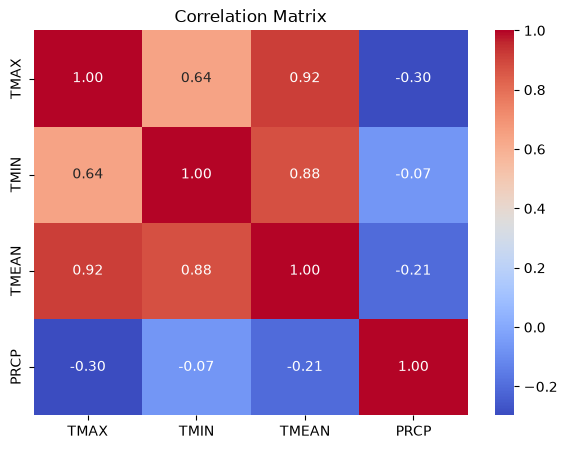

In [10]:
corr = df[["TMAX", "TMIN", "TMEAN", "PRCP"]].corr()
print(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

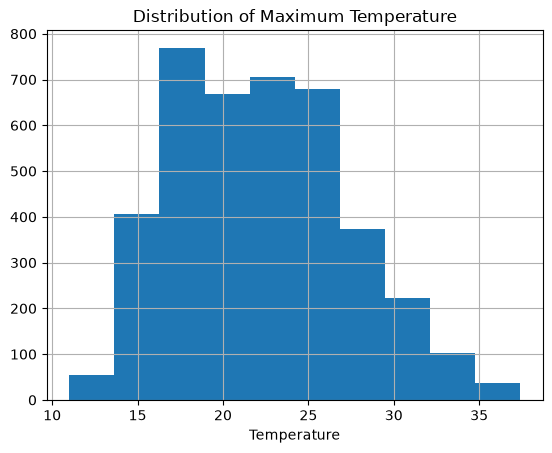

In [11]:
df["TMAX"].hist()
plt.title("Distribution of Maximum Temperature")
plt.xlabel("Temperature")
plt.show()

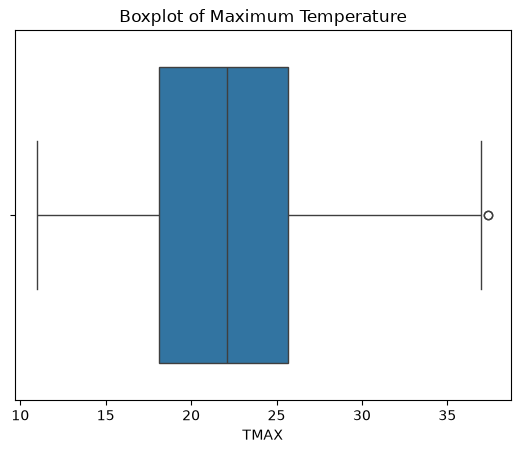

In [12]:
sns.boxplot(x=df["TMAX"])
plt.title("Boxplot of Maximum Temperature")
plt.show()

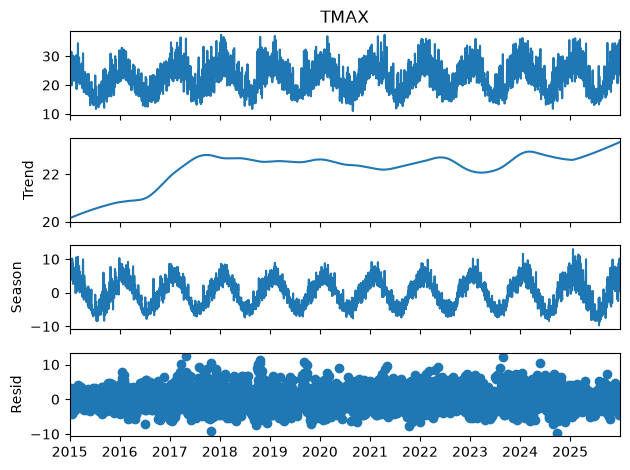

In [13]:
df_stl = df.set_index("time")

stl = STL(df_stl["TMAX"], period=365)
result = stl.fit()

result.plot()
plt.show()

### 4. Feature Engineering

In [14]:
df["TMAX_next"] = df["TMAX"].shift(-1)

In [15]:
df["TMAX_lag1"] = df["TMAX"].shift(1)
df["TMAX_lag2"] = df["TMAX"].shift(2)
df["TMAX_lag3"] = df["TMAX"].shift(3)

In [16]:
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.dayofyear

In [17]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["day_sin"] = np.sin(2 * np.pi * df["day"] / 365)
df["day_cos"] = np.cos(2 * np.pi * df["day"] / 365)

In [18]:
df.isnull().sum()

time               0
TMAX               0
TMIN               0
TMEAN              0
PRCP               0
TMAX_30day_avg    29
month              0
TMAX_next          1
TMAX_lag1          1
TMAX_lag2          2
TMAX_lag3          3
day                0
month_sin          0
month_cos          0
day_sin            0
day_cos            0
dtype: int64

In [19]:
model_columns = [
    "TMAX_next",
    "TMAX_lag1",
    "TMAX_lag2",
    "TMAX_lag3",
    "TMIN",
    "TMEAN",
    "PRCP",
    "month",
    "day",
    "month_sin",
    "month_cos",
    "day_sin",
    "day_cos"
]

df_model = df.dropna(subset=model_columns).copy()
df_model = df_model.sort_values("time").reset_index(drop=True)

### 5. Define Features and Target

In [20]:
features = ["TMIN", "TMEAN", "PRCP", "TMAX_lag1", "TMAX_lag2", "TMAX_lag3", "month_sin", "month_cos", "day_sin", "day_cos"]
X = df_model[features]
y = df_model["TMAX_next"]

In [21]:
dates = df_model["time"]

### 6. Split Data

In [22]:
print("Length of df:", len(df))
print("Length of df_model:", len(df_model))

Length of df: 4018
Length of df_model: 4014


In [23]:
n = len(df_model)

train_end = int(n * 0.70)
cal_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_cal = X.iloc[train_end:cal_end]
y_cal = y.iloc[train_end:cal_end]

X_test = X.iloc[cal_end:]
y_test = y.iloc[cal_end:]

dates_test = dates.iloc[cal_end:]

print("Training size:", len(X_train))
print("Calibration size:", len(X_cal))
print("Test size:", len(X_test))

Training size: 2809
Calibration size: 602
Test size: 603


In [24]:
print("Training dates:")
print(dates.iloc[:train_end].min(), "to", dates.iloc[:train_end].max())

print("Calibration dates:")
print(dates.iloc[train_end:cal_end].min(), "to", dates.iloc[train_end:cal_end].max())

print("Test dates:")
print(dates.iloc[cal_end:].min(), "to", dates.iloc[cal_end:].max())

Training dates:
2015-01-04 00:00:00 to 2022-09-12 00:00:00
Calibration dates:
2022-09-13 00:00:00 to 2024-05-06 00:00:00
Test dates:
2024-05-07 00:00:00 to 2025-12-30 00:00:00


### 7. Define models

In [25]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42),

    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            max_iter=1000,
            random_state=42))])}

### 8. Fit all models and evaluate point predictions

In [26]:
point_results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    point_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

point_results_df = pd.DataFrame(point_results)
point_results_df

Training Random Forest...
Training XGBoost...
Training MLP...


,Model,MAE,RMSE,R2
0,Random Forest,2.352730,3.098425,0.654042
1,XGBoost,2.368994,3.138921,0.644939
2,MLP,2.272649,3.074553,0.659352


### 8. Apply Conformal Prediction to all three models

In [27]:
conformal_results = {}
summary_results = []

confidence_level = 0.90

for name, model in trained_models.items():
    print(f"Applying conformal prediction to {name}...")
    
    cp_model = SplitConformalRegressor(
        estimator=model,
        confidence_level=confidence_level,
        prefit=True)
    
    cp_model.conformalize(X_cal, y_cal)
    
    y_pred, intervals = cp_model.predict_interval(X_test)
    
    lower = intervals[:, 0, 0]
    upper = intervals[:, 1, 0]
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    coverage = ((y_test >= lower) & (y_test <= upper)).mean()
    avg_width = np.mean(upper - lower)
    
    summary_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Coverage": coverage,
        "Average Interval Width": avg_width})
    
    conformal_results[name] = {
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper}

results_df = pd.DataFrame(summary_results)
results_df

Applying conformal prediction to Random Forest...
Applying conformal prediction to XGBoost...
Applying conformal prediction to MLP...


,Model,MAE,RMSE,R2,Coverage,Average Interval Width
0,Random Forest,2.352730,3.098425,0.654042,0.888889,10.118667
1,XGBoost,2.368994,3.138921,0.644939,0.895522,10.272527
2,MLP,2.272649,3.074553,0.659352,0.897181,10.165261


### 9. Model comparison tables

In [28]:
results_df.sort_values(by="MAE")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
2,MLP,2.272649,3.074553,0.659352,0.897181,10.165261
0,Random Forest,2.352730,3.098425,0.654042,0.888889,10.118667
1,XGBoost,2.368994,3.138921,0.644939,0.895522,10.272527


In [29]:
results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
2,MLP,2.272649,3.074553,0.659352,0.897181,10.165261
0,Random Forest,2.352730,3.098425,0.654042,0.888889,10.118667
1,XGBoost,2.368994,3.138921,0.644939,0.895522,10.272527


In [30]:
results_df.sort_values(by="Average Interval Width")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
0,Random Forest,2.352730,3.098425,0.654042,0.888889,10.118667
2,MLP,2.272649,3.074553,0.659352,0.897181,10.165261
1,XGBoost,2.368994,3.138921,0.644939,0.895522,10.272527


### 10. Plot predictions and conformal intervals on (XGBoost)

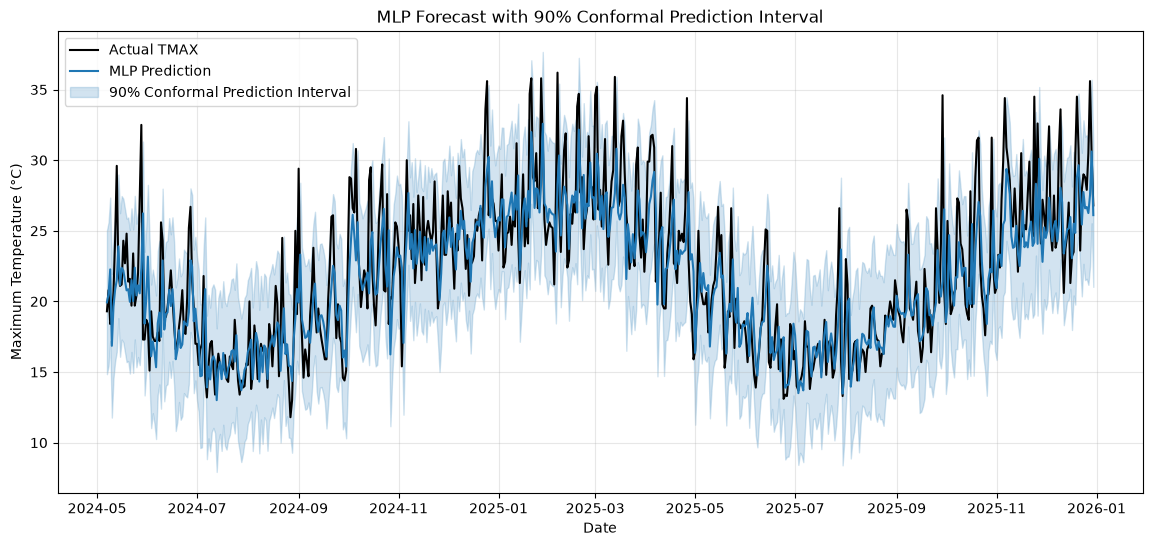

In [31]:
model_name = "MLP"

pred = conformal_results[model_name]["y_pred"]
lower = conformal_results[model_name]["lower"]
upper = conformal_results[model_name]["upper"]

plt.figure(figsize=(14, 6))

plt.plot(dates_test, y_test.values, label="Actual TMAX", color="black", linewidth=1.5)
plt.plot(dates_test, pred, label=f"{model_name} Prediction", color="tab:blue", linewidth=1.5)

plt.fill_between(
    dates_test,
    lower,
    upper,
    color="tab:blue",
    alpha=0.2,
    label="90% Conformal Prediction Interval")

plt.title(f"{model_name} Forecast with 90% Conformal Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 11. Plot all model results as bar charts

#### MAE comparison

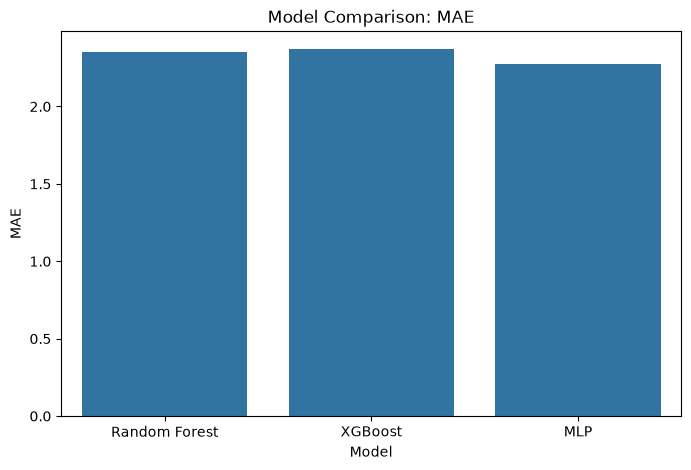

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="MAE")
plt.title("Model Comparison: MAE")
plt.ylabel("MAE")
plt.show()

#### RMSE comparison

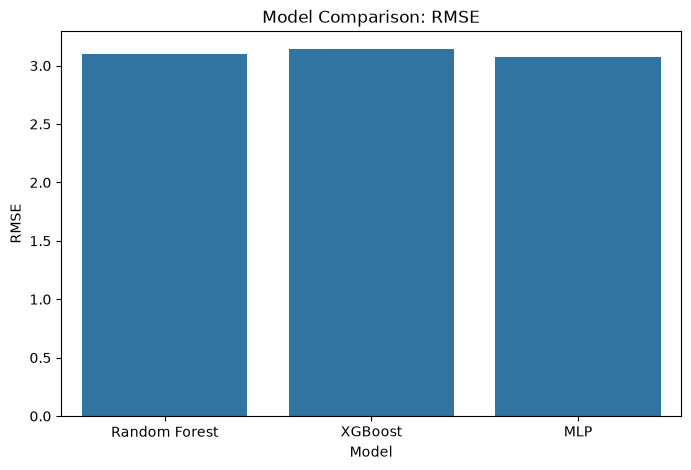

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.show()

#### Coverage comparison

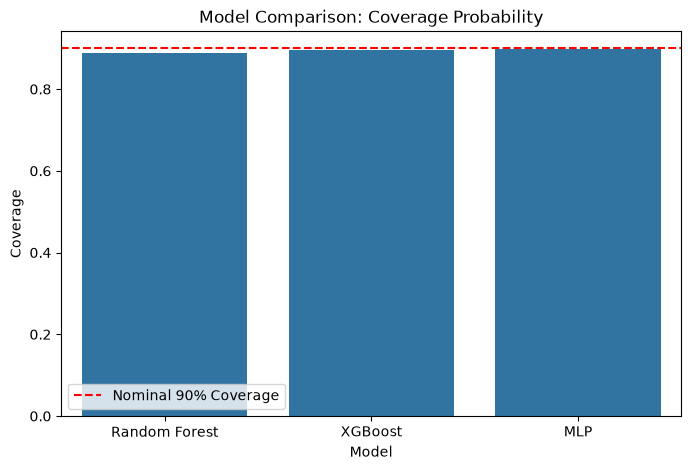

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Coverage")
plt.axhline(0.90, color="red", linestyle="--", label="Nominal 90% Coverage")
plt.title("Model Comparison: Coverage Probability")
plt.ylabel("Coverage")
plt.legend()
plt.show()

#### Interval width comparison

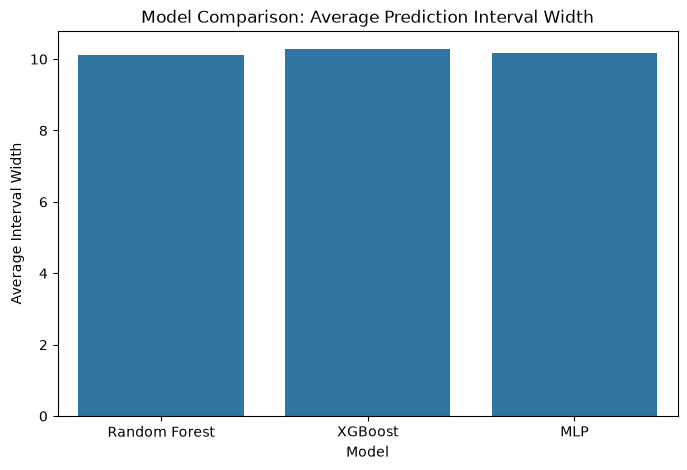

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="Average Interval Width")
plt.title("Model Comparison: Average Prediction Interval Width")
plt.ylabel("Average Interval Width")
plt.show()

### 12. Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [None, 10, 20],
            "min_samples_leaf": [1, 2]}},

    "XGBoost": {
        "model": XGBRegressor(
            objective="reg:squarederror",
            random_state=42),
        "params": {
            "n_estimators": [100, 300],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]}},

    "MLP": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                max_iter=1000,
                random_state=42
            ))]),
        "params": {
            "mlp__hidden_layer_sizes": [(64,), (64, 32)],
            "mlp__activation": ["relu"],
            "mlp__learning_rate_init": [0.001],
            "mlp__alpha": [0.0001, 0.001]}}}

In [37]:
best_models = {}
tuning_results = []

for name, item in models.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=item["model"],
        param_grid=item["params"],
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1)

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best Parameters": grid.best_params_,
        "Best CV MAE": -grid.best_score_})

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df

Tuning Random Forest...
Tuning XGBoost...
Tuning MLP...


,Model,Best Parameters,Best CV MAE
0,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",2.320150
1,XGBoost,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",2.305429
2,MLP,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00...",2.363338


### Apply Conformal prediction to tuned models

In [38]:
results = []
tuned_conformal_results = {}

confidence_level = 0.90

for name, model in best_models.items():
    print(f"Applying conformal prediction to {name}...")

    cp_model = SplitConformalRegressor(
        estimator=model,
        confidence_level=confidence_level,
        prefit=True)

    cp_model.conformalize(X_cal, y_cal)

    y_pred, intervals = cp_model.predict_interval(X_test)

    lower = intervals[:, 0, 0]
    upper = intervals[:, 1, 0]

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    coverage = ((y_test >= lower) & (y_test <= upper)).mean()
    avg_width = np.mean(upper - lower)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Coverage": coverage,
        "Average Interval Width": avg_width})

    tuned_conformal_results[name] = {
        "Prediction": y_pred,
        "Lower": lower,
        "Upper": upper}

tuned_results_df = pd.DataFrame(results)
tuned_results_df

Applying conformal prediction to Random Forest...
Applying conformal prediction to XGBoost...
Applying conformal prediction to MLP...


,Model,MAE,RMSE,R2,Coverage,Average Interval Width
0,Random Forest,2.324889,3.066013,0.661242,0.888889,10.107573
1,XGBoost,2.322914,3.103567,0.652892,0.882255,9.640878
2,MLP,2.264144,3.036135,0.667812,0.893864,9.894449


### Best Performing tuned model

In [39]:
tuned_results_df.sort_values(by="MAE")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
2,MLP,2.264144,3.036135,0.667812,0.893864,9.894449
1,XGBoost,2.322914,3.103567,0.652892,0.882255,9.640878
0,Random Forest,2.324889,3.066013,0.661242,0.888889,10.107573


In [40]:
tuned_results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
2,MLP,2.264144,3.036135,0.667812,0.893864,9.894449
0,Random Forest,2.324889,3.066013,0.661242,0.888889,10.107573
1,XGBoost,2.322914,3.103567,0.652892,0.882255,9.640878


In [41]:
tuned_results_df.sort_values(by="Average Interval Width")

,Model,MAE,RMSE,R2,Coverage,Average Interval Width
1,XGBoost,2.322914,3.103567,0.652892,0.882255,9.640878
2,MLP,2.264144,3.036135,0.667812,0.893864,9.894449
0,Random Forest,2.324889,3.066013,0.661242,0.888889,10.107573


In [42]:
tuned_conformal_results = {}
tuned_summary_results = []

confidence_level = 0.9

for name, model in best_models.items():
    print(f"Applying conformal prediction to tuned {name}...")

    cp_model = SplitConformalRegressor(
        estimator=model,
        confidence_level=confidence_level,
        prefit=True)

    cp_model.conformalize(X_cal, y_cal)

    y_pred, intervals = cp_model.predict_interval(X_test)

    lower = intervals[:, 0, 0]
    upper = intervals[:, 1, 0]

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    coverage = ((y_test >= lower) & (y_test <= upper)).mean()
    avg_width = np.mean(upper - lower)

    tuned_summary_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Coverage": coverage,
        "Average Interval Width": avg_width})

    tuned_conformal_results[name] = {
        "y_pred": y_pred,
        "lower": lower,
        "upper": upper}

tuned_results_df = pd.DataFrame(tuned_summary_results)
tuned_results_df

Applying conformal prediction to tuned Random Forest...
Applying conformal prediction to tuned XGBoost...
Applying conformal prediction to tuned MLP...


,Model,MAE,RMSE,R2,Coverage,Average Interval Width
0,Random Forest,2.324889,3.066013,0.661242,0.888889,10.107573
1,XGBoost,2.322914,3.103567,0.652892,0.882255,9.640878
2,MLP,2.264144,3.036135,0.667812,0.893864,9.894449


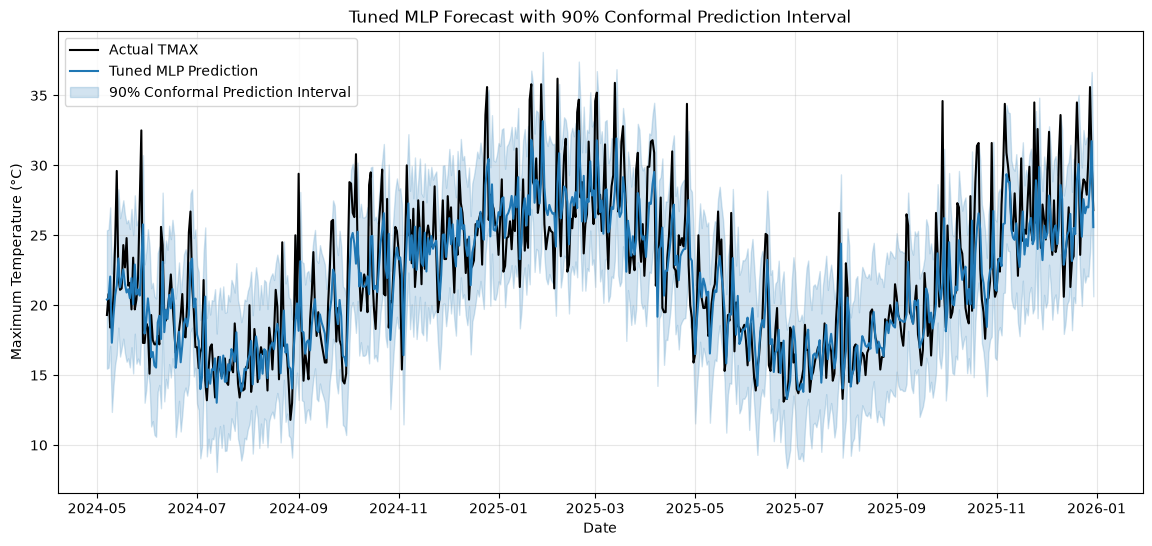

In [43]:
model_name = "MLP"

pred = tuned_conformal_results[model_name]["y_pred"]
lower = tuned_conformal_results[model_name]["lower"]
upper = tuned_conformal_results[model_name]["upper"]

plt.figure(figsize=(14, 6))

plt.plot(
    dates_test,
    y_test.values,
    label="Actual TMAX",
    color="black",
    linewidth=1.5)

plt.plot(
    dates_test,
    pred,
    label="Tuned MLP Prediction",
    color="tab:blue",
    linewidth=1.5)

plt.fill_between(
    dates_test,
    lower,
    upper,
    color="tab:blue",
    alpha=0.2,
    label="90% Conformal Prediction Interval")

plt.title("Tuned MLP Forecast with 90% Conformal Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

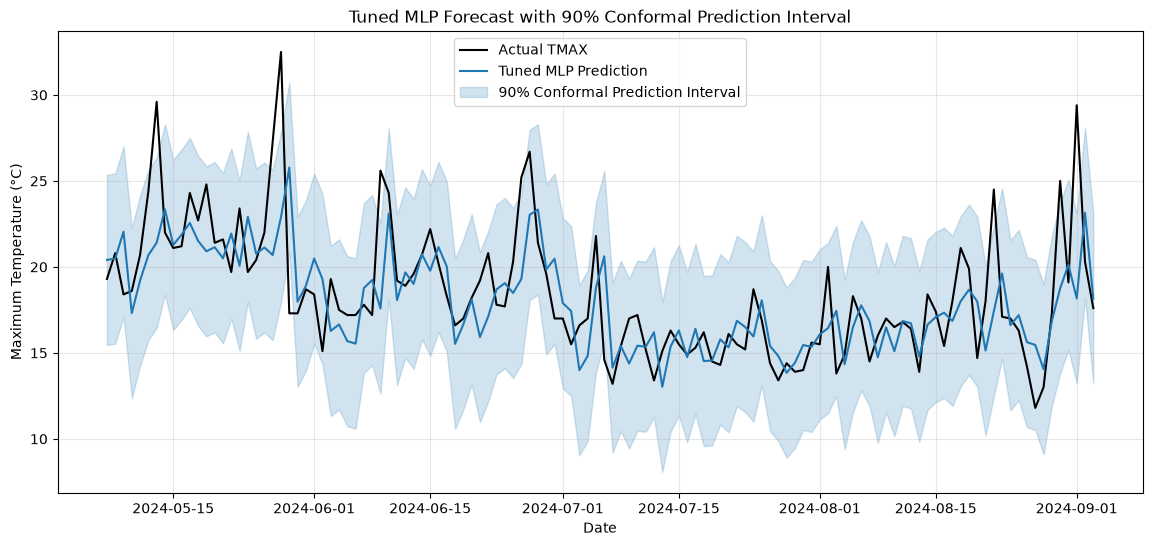

In [44]:
model_name = "MLP"
n_plot = 120

pred = tuned_conformal_results[model_name]["y_pred"]
lower = tuned_conformal_results[model_name]["lower"]
upper = tuned_conformal_results[model_name]["upper"]

plt.figure(figsize=(14, 6))

plt.plot(
    dates_test.iloc[:n_plot],
    y_test.values[:n_plot],
    label="Actual TMAX",
    color="black",
    linewidth=1.5)

plt.plot(
    dates_test.iloc[:n_plot],
    pred[:n_plot],
    label="Tuned MLP Prediction",
    color="tab:blue",
    linewidth=1.5)

plt.fill_between(
    dates_test.iloc[:n_plot],
    lower[:n_plot],
    upper[:n_plot],
    color="tab:blue",
    alpha=0.2,
    label="90% Conformal Prediction Interval")

plt.title("Tuned MLP Forecast with 90% Conformal Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [45]:
print(best_models.keys())

dict_keys(['Random Forest', 'XGBoost', 'MLP'])


### Save Results

In [46]:
df_model.to_csv("processed_temperature_data.csv", index=False)

In [47]:
tuning_results_df.to_csv("hyperparameter_tuning_results.csv", index=False)
tuned_results_df.to_csv("tuned_conformal_results.csv", index=False)

## Effect of Confidence Level on Prediction Interval Width and Coverage

In [48]:
confidence_levels = [0.80, 0.90, 0.95]

coverage_results = []

for confidence_level in confidence_levels:
    
    for name, model in best_models.items():
        print(f"Model: {name}, Confidence level: {confidence_level}")

        cp_model = SplitConformalRegressor(
            estimator=model,
            confidence_level=confidence_level,
            prefit=True)

        cp_model.conformalize(X_cal, y_cal)

        y_pred, intervals = cp_model.predict_interval(X_test)

        lower = intervals[:, 0, 0]
        upper = intervals[:, 1, 0]

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        coverage = ((y_test >= lower) & (y_test <= upper)).mean()
        avg_width = np.mean(upper - lower)

        coverage_results.append({
            "Model": name,
            "Confidence Level": confidence_level,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "Coverage": coverage,
            "Average Interval Width": avg_width})

coverage_results_df = pd.DataFrame(coverage_results)
coverage_results_df

Model: Random Forest, Confidence level: 0.8
Model: XGBoost, Confidence level: 0.8
Model: MLP, Confidence level: 0.8
Model: Random Forest, Confidence level: 0.9
Model: XGBoost, Confidence level: 0.9
Model: MLP, Confidence level: 0.9
Model: Random Forest, Confidence level: 0.95
Model: XGBoost, Confidence level: 0.95
Model: MLP, Confidence level: 0.95


,Model,Confidence Level,MAE,RMSE,R2,Coverage,Average Interval Width
0,Random Forest,0.80,2.324889,3.066013,0.661242,0.804312,7.575886
1,XGBoost,0.80,2.322914,3.103567,0.652892,0.796020,7.317374
2,MLP,0.80,2.264144,3.036135,0.667812,0.819237,7.560020
3,Random Forest,0.90,2.324889,3.066013,0.661242,0.888889,10.107573
4,XGBoost,0.90,2.322914,3.103567,0.652892,0.882255,9.640878
5,MLP,0.90,2.264144,3.036135,0.667812,0.893864,9.894449
6,Random Forest,0.95,2.324889,3.066013,0.661242,0.946932,12.503956
7,XGBoost,0.95,2.322914,3.103567,0.652892,0.927032,11.880464
8,MLP,0.95,2.264144,3.036135,0.667812,0.933665,11.731103


In [49]:
coverage_results_df.sort_values(
    by=["Model", "Confidence Level"])

,Model,Confidence Level,MAE,RMSE,R2,Coverage,Average Interval Width
2,MLP,0.80,2.264144,3.036135,0.667812,0.819237,7.560020
5,MLP,0.90,2.264144,3.036135,0.667812,0.893864,9.894449
8,MLP,0.95,2.264144,3.036135,0.667812,0.933665,11.731103
0,Random Forest,0.80,2.324889,3.066013,0.661242,0.804312,7.575886
3,Random Forest,0.90,2.324889,3.066013,0.661242,0.888889,10.107573
6,Random Forest,0.95,2.324889,3.066013,0.661242,0.946932,12.503956
1,XGBoost,0.80,2.322914,3.103567,0.652892,0.796020,7.317374
4,XGBoost,0.90,2.322914,3.103567,0.652892,0.882255,9.640878
7,XGBoost,0.95,2.322914,3.103567,0.652892,0.927032,11.880464


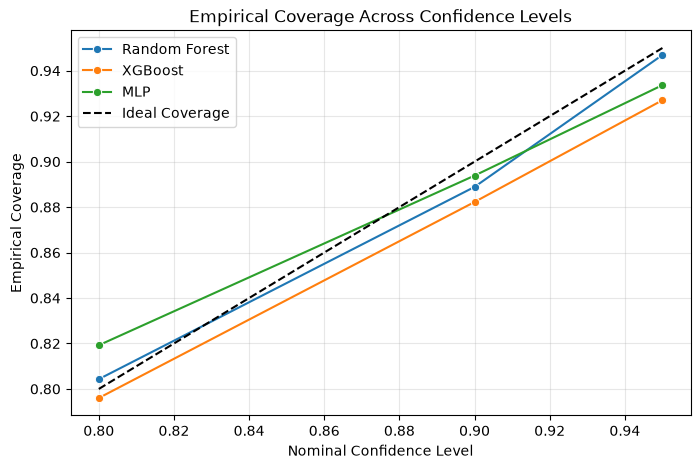

In [50]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=coverage_results_df,
    x="Confidence Level",
    y="Coverage",
    hue="Model",
    marker="o")

plt.plot([0.80, 0.95], [0.80, 0.95], linestyle="--", color="black", label="Ideal Coverage")

plt.title("Empirical Coverage Across Confidence Levels")
plt.xlabel("Nominal Confidence Level")
plt.ylabel("Empirical Coverage")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

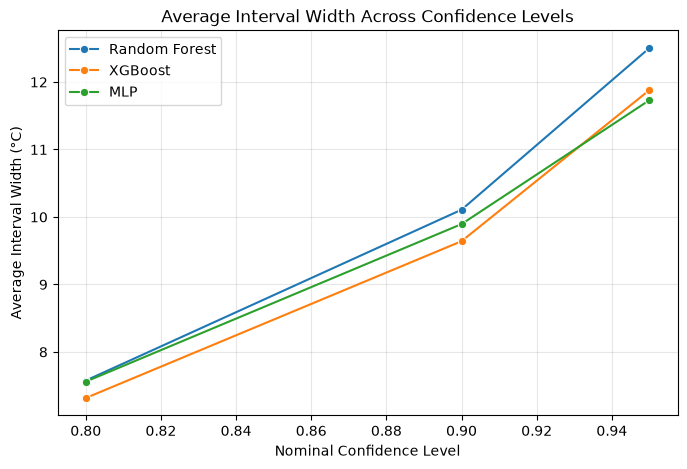

In [51]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=coverage_results_df,
    x="Confidence Level",
    y="Average Interval Width",
    hue="Model",
    marker="o")

plt.title("Average Interval Width Across Confidence Levels")
plt.xlabel("Nominal Confidence Level")
plt.ylabel("Average Interval Width (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Non-Conformal Gaussian Residual Interval Baseline

In [52]:
import numpy as np
import pandas as pd
from scipy.stats import norm

confidence_levels = [0.80, 0.90, 0.95]

gaussian_results = []

for name, model in best_models.items():
    print(f"Calculating Gaussian intervals for {name}...")

    # Predictions on calibration and test sets
    cal_pred = model.predict(X_cal)
    test_pred = model.predict(X_test)

    # Calibration residuals
    cal_residuals = y_cal.values - cal_pred

    # Residual mean and sample standard deviation
    residual_mean = np.mean(cal_residuals)
    residual_std = np.std(cal_residuals, ddof=1)

    for confidence_level in confidence_levels:
        alpha = 1 - confidence_level
        z_value = norm.ppf(1 - alpha / 2)

        # Gaussian residual prediction intervals
        lower = (
            test_pred
            + residual_mean
            - z_value * residual_std
        )

        upper = (
            test_pred
            + residual_mean
            + z_value * residual_std
        )

        coverage = (
            (y_test.values >= lower)
            & (y_test.values <= upper)
        ).mean()

        avg_width = np.mean(upper - lower)

        gaussian_results.append({
            "Model": name,
            "Method": "Gaussian Residual",
            "Confidence Level": confidence_level,
            "Coverage": coverage,
            "Average Interval Width": avg_width,
            "Residual Mean": residual_mean,
            "Residual Standard Deviation": residual_std
        })

gaussian_results_df = pd.DataFrame(gaussian_results)

gaussian_results_df

Calculating Gaussian intervals for Random Forest...
Calculating Gaussian intervals for XGBoost...
Calculating Gaussian intervals for MLP...


,Model,Method,Confidence Level,Coverage,Average Interval Width,Residual Mean,Residual Standard Deviation
0,Random Forest,Gaussian Residual,0.80,0.799337,7.547250,0.497934,2.944575
1,Random Forest,Gaussian Residual,0.90,0.883914,9.686790,0.497934,2.944575
2,Random Forest,Gaussian Residual,0.95,0.930348,11.542522,0.497934,2.944575
3,XGBoost,Gaussian Residual,0.80,0.797678,7.407331,0.517991,2.889985
4,XGBoost,Gaussian Residual,0.90,0.880597,9.507206,0.517991,2.889985
5,XGBoost,Gaussian Residual,0.95,0.930348,11.328535,0.517991,2.889985
6,MLP,Gaussian Residual,0.80,0.812604,7.451383,0.353203,2.907172
7,MLP,Gaussian Residual,0.90,0.892206,9.563746,0.353203,2.907172
8,MLP,Gaussian Residual,0.95,0.927032,11.395907,0.353203,2.907172


In [53]:
print("Number of rows:", len(gaussian_results_df))

print("\nMissing values:")
print(gaussian_results_df.isnull().sum())

print("\nCoverage range:")
print(
    gaussian_results_df["Coverage"].min(),
    gaussian_results_df["Coverage"].max()
)

print("\nInterval width range:")
print(
    gaussian_results_df["Average Interval Width"].min(),
    gaussian_results_df["Average Interval Width"].max()
)

Number of rows: 9

Missing values:
Model                          0
Method                         0
Confidence Level               0
Coverage                       0
Average Interval Width         0
Residual Mean                  0
Residual Standard Deviation    0
dtype: int64

Coverage range:
0.7976782752902156 0.9303482587064676

Interval width range:
7.407330797467182 11.542522348230955


In [54]:
conformal_comparison_df = coverage_results_df[
    [
        "Model",
        "Confidence Level",
        "Coverage",
        "Average Interval Width"
    ]
].copy()

conformal_comparison_df["Method"] = "Split Conformal"

gaussian_comparison_df = gaussian_results_df[
    [
        "Model",
        "Method",
        "Confidence Level",
        "Coverage",
        "Average Interval Width"
    ]
].copy()

interval_comparison_df = pd.concat(
    [
        gaussian_comparison_df,
        conformal_comparison_df
    ],
    ignore_index=True
)

interval_comparison_df = interval_comparison_df[
    [
        "Model",
        "Method",
        "Confidence Level",
        "Coverage",
        "Average Interval Width"
    ]
].sort_values(
    by=["Model", "Confidence Level", "Method"]
).reset_index(drop=True)

interval_comparison_df

,Model,Method,Confidence Level,Coverage,Average Interval Width
0,MLP,Gaussian Residual,0.80,0.812604,7.451383
1,MLP,Split Conformal,0.80,0.819237,7.560020
2,MLP,Gaussian Residual,0.90,0.892206,9.563746
3,MLP,Split Conformal,0.90,0.893864,9.894449
4,MLP,Gaussian Residual,0.95,0.927032,11.395907
5,MLP,Split Conformal,0.95,0.933665,11.731103
6,Random Forest,Gaussian Residual,0.80,0.799337,7.547250
7,Random Forest,Split Conformal,0.80,0.804312,7.575886
8,Random Forest,Gaussian Residual,0.90,0.883914,9.686790
9,Random Forest,Split Conformal,0.90,0.888889,10.107573


In [55]:
print("Expected 18 rows. Actual rows:", len(interval_comparison_df))

Expected 18 rows. Actual rows: 18


In [56]:
comparison_90_df = interval_comparison_df[
    interval_comparison_df["Confidence Level"] == 0.90
].copy()

comparison_90_df["Confidence Level"] = (
    comparison_90_df["Confidence Level"] * 100
).astype(int).astype(str) + "%"

comparison_90_df["Coverage"] = (
    comparison_90_df["Coverage"] * 100
).round(2)

comparison_90_df["Average Interval Width"] = (
    comparison_90_df["Average Interval Width"]
).round(2)

comparison_90_df

,Model,Method,Confidence Level,Coverage,Average Interval Width
2,MLP,Gaussian Residual,90%,89.22,9.56
3,MLP,Split Conformal,90%,89.39,9.89
8,Random Forest,Gaussian Residual,90%,88.39,9.69
9,Random Forest,Split Conformal,90%,88.89,10.11
14,XGBoost,Gaussian Residual,90%,88.06,9.51
15,XGBoost,Split Conformal,90%,88.23,9.64


In [57]:
gaussian_results_df.to_csv(
    "gaussian_residual_interval_results.csv",
    index=False
)

interval_comparison_df.to_csv(
    "gaussian_vs_conformal_interval_results.csv",
    index=False
)

comparison_90_df.to_csv(
    "gaussian_vs_conformal_90_percent.csv",
    index=False
)